# Policy Updates in One State — The Multi-Armed Bandit

Reinforcement learning is usually states, actions, rewards, and a policy $\pi(a \mid s)$ we keep improving.
Let's strip it to the bone: **one fixed state** (so we drop $s$ entirely), $n$ actions, each paying a fixed
reward. What remains is a single probability vector $\pi$ and one question: *how do we nudge it toward the
actions that pay best?*

This stripped-down problem has a name — the **multi-armed bandit**, after slot machines ("one-armed bandits").
And it isn't just a toy: as we'll see at the end, a bandit problem sits at the heart of AlphaZero's search.

## 1. Setup

$n = 4$ arms with deterministic rewards $r = [1.0,\ 2.0,\ 3.0,\ 2.5]$. The policy is a softmax over logits
$\theta \in \mathbb{R}^n$, initialized at $\theta = 0$ (the uniform policy):

$$J(\theta) = \mathbb{E}_{a \sim \pi_\theta}[r_a] = \sum_a \pi_\theta(a)\, r_a,
\qquad
\pi_\theta(a) = \frac{e^{\theta_a}}{\sum_b e^{\theta_b}}.$$

The policy gradient has a beautiful closed form. Since
$\frac{\partial \pi_b}{\partial \theta_a} = \pi_b(\delta_{ab} - \pi_a)$,

$$\frac{\partial J}{\partial \theta_a}
= \sum_b r_b\,\frac{\partial \pi_b}{\partial \theta_a}
= \pi_a\left(r_a - \underbrace{\sum_b \pi_b r_b}_{J(\theta)}\right).$$

In vector form: $\nabla_\theta J = \pi \odot (r - J)$. Each step raises the logit of every arm beating the
current average reward and lowers the rest — a pure "do more of what works" update:

$$\theta \leftarrow \theta + \alpha\,\pi \odot (r - J).$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0
np.random.seed(SEED)

# --- the bandit: one fixed reward per arm ---
rewards = np.array([1.0, 2.0, 3.0, 2.5])
n = len(rewards)
ALPHA = 0.5    # step size
ITERS = 300

def softmax(theta):
    z = theta - theta.max()
    e = np.exp(z)
    return e / e.sum()

# --- policy gradient ascent, starting from the uniform policy ---
theta = np.zeros(n)
pi_hist, J_hist, H_hist = [], [], []
for _ in range(ITERS):
    pi = softmax(theta)
    J = float(pi @ rewards)
    theta += ALPHA * pi * (rewards - J)   # dJ/dtheta = pi * (r - J)
    pi_hist.append(pi)
    J_hist.append(J)
    H_hist.append(float(-np.sum(pi * np.log(pi + 1e-12))))

pi_hist, J_hist, H_hist = map(np.array, (pi_hist, J_hist, H_hist))
pi_final = softmax(theta)
print("final policy:    ", np.round(pi_final, 4))
print("expected reward:  %.4f (best arm pays %.1f)" % (J_hist[-1], rewards.max()))

final policy:     [9.000e-04 1.800e-03 9.937e-01 3.600e-03]
expected reward:  2.9946 (best arm pays 3.0)


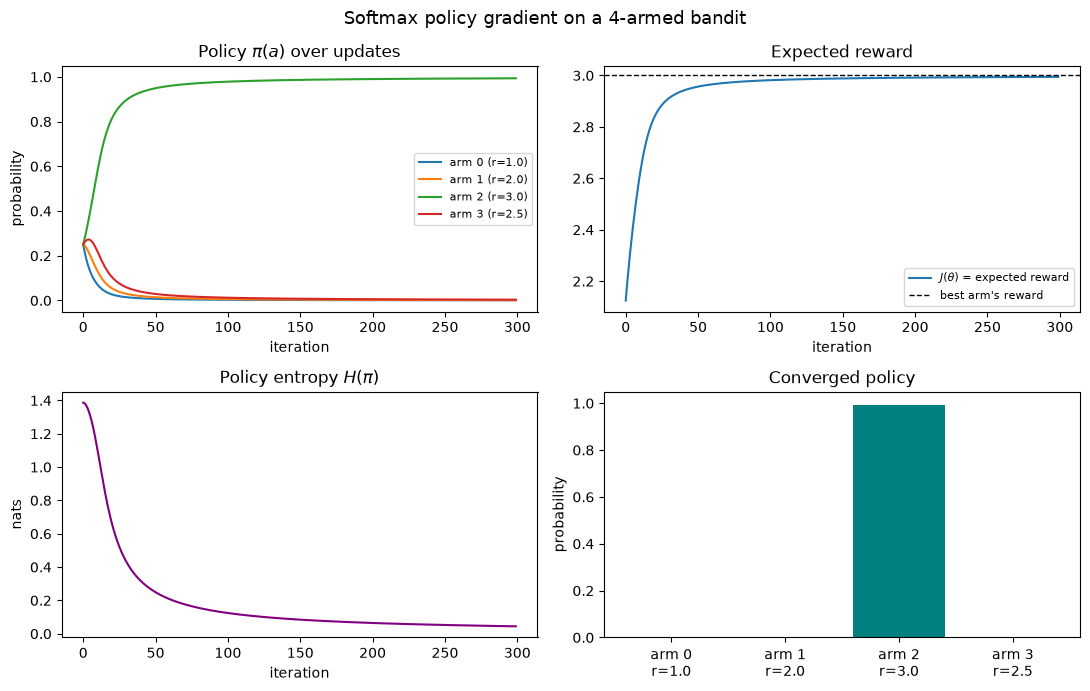

In [2]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
t = np.arange(ITERS)

for a in range(n):
    ax[0, 0].plot(t, pi_hist[:, a], label=f"arm {a} (r={rewards[a]:.1f})")
ax[0, 0].set_title("Policy $\\pi(a)$ over updates")
ax[0, 0].set_xlabel("iteration"); ax[0, 0].set_ylabel("probability")
ax[0, 0].legend(fontsize=8); ax[0, 0].set_ylim(-0.05, 1.05)

ax[0, 1].plot(t, J_hist, label="$J(\\theta)$ = expected reward")
ax[0, 1].axhline(rewards.max(), ls="--", c="k", lw=1, label="best arm's reward")
ax[0, 1].set_title("Expected reward")
ax[0, 1].set_xlabel("iteration"); ax[0, 1].legend(fontsize=8)

ax[1, 0].plot(t, H_hist, c="purple")
ax[1, 0].set_title("Policy entropy $H(\\pi)$")
ax[1, 0].set_xlabel("iteration"); ax[1, 0].set_ylabel("nats")

ax[1, 1].bar(range(n), pi_final,
             tick_label=[f"arm {a}\nr={rewards[a]:.1f}" for a in range(n)],
             color="teal")
ax[1, 1].set_title("Converged policy")
ax[1, 1].set_ylim(0, 1.05); ax[1, 1].set_ylabel("probability")

fig.suptitle("Softmax policy gradient on a 4-armed bandit", fontsize=13)
fig.tight_layout()
plt.show()

## 2. Where it converges

The policy converges to (almost) a one-hot on arm 2 — the arm paying 3.0 — and the expected reward
converges to 3.0. Two things worth noticing:

1. **Why it stops.** The gradient is $\pi_a (r_a - J)$. As $\pi$ concentrates on the best arm,
$J \to r_{\text{best}}$ and every component of the gradient goes to zero: $\pi_a = 0$ for the losers,
$(r_a - J) = 0$ for the winner. The greedy policy is a fixed point.
2. **The fine print.** This update is *pure exploitation* — it only ever reinforces what's already ahead.
With deterministic rewards that's fine. But if the rewards were noisy *estimates* (as they always are in real
RL), an early lucky pull could lock the policy onto a suboptimal arm forever, because a near-zero $\pi_a$
means a near-zero gradient: the policy can never climb back. That failure mode is the whole reason
exploration exists — which brings us to the next two sections.

## 3. This has a name: the multi-armed bandit

What we just ran is the **multi-armed bandit** problem (Robbins, 1952): $n$ slot machines ("one-armed bandits"),
pull one per round, maximize total reward. The central tension is **exploration vs. exploitation** — learning
which arm is best versus pulling the one that currently looks best.

The classical answers all address the failure mode from §2:
- **$\varepsilon$-greedy**: pull the best arm most of the time, a random arm with probability $\varepsilon$.
- **UCB** (upper confidence bounds): pull $\arg\max_a \left[ \hat{r}_a + c\sqrt{\ln t / N_a} \right]$ —
optimism in the face of uncertainty; the bonus keeps under-sampled arms alive.
- **Thompson sampling**: maintain a posterior over each arm's reward and sample from it.

Our gradient update is the *exploit* half of the problem written in its purest possible form — which is
exactly why it's the right starting point before adding exploration machinery.

## 4. Connection to AlphaZero

In AlphaZero the policy is $\pi(a \mid s)$ — a distribution over moves, the same object as our $\pi$, just
conditioned on a board state. The network's policy head is trained with cross-entropy against the MCTS
visit-count distribution: move probability mass toward what the search found to be good. That is a policy
update of the same family as the gradient step above.

But the connection runs deeper than analogy. MCTS's selection rule, **PUCT**,

$$a^* = \arg\max_a \left[ Q(s,a) + c_{\text{puct}}\, P(s,a)\, \frac{\sqrt{N(s)}}{1 + N(s,a)} \right],$$

*is* a bandit algorithm: UCT is literally "UCB applied to trees" (Kocsis & Szepesvári, 2006). Every node of the
search tree faces a bandit problem — which child to pull next — trading off $Q(s,a)$ (exploit) against the
visit-count bonus (explore). The Dirichlet noise on the root priors is forced exploration: it stops the policy
from collapsing onto the first promising move before the search has looked around — precisely the
premature-lock-in failure mode from §2.

So: the bandit is AlphaZero with $|S| = 1$ and no tree. And the tree is bandits all the way down.

## Exercises

1. **Noisy rewards.** Replace the fixed $r$ with samples $r_a \sim \mathcal{N}(\mu_a, 1)$ and use the *sampled*
reward in the gradient. Run it 20 times: how often does the policy lock onto the wrong arm? Then fix it —
add $\varepsilon$-greedy action selection or a UCB-style bonus and compare.
2. **Step size.** Try $\alpha = 0.05$ and $\alpha = 5.0$. What breaks at each extreme?
3. **Temperature.** Use $\pi(a) \propto \exp(\theta_a / \tau)$. How does the converged policy change with $\tau$?
(There is a reason softmax policies in practice rarely converge to a hard one-hot.)
4. **Policy gradient theorem.** Our derivation used the exact gradient. Rewrite the loop with the score-function
estimator $\nabla J = \mathbb{E}[r_a \nabla \log \pi(a)]$ over *sampled* actions — that's REINFORCE, and it's
the form the theorem takes when you can't sum over all actions.